# Taller 04: Descubriendo Patrones Musicales con Spotify

Dataset: 999 canciones populares 2023 con sus audio features  
Fuente: https://www.kaggle.com/datasets/glowstudygram/spotify-songs-and-artists-dataset

**Pipeline:** Preprocesamiento → Estandarización → PCA → K-Means + DBSCAN → Interpretación

---
## Bloque 1: Configuración y Carga de Datos

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_csv('spotifydataset.csv')
df.shape

(1000, 23)

In [22]:
df.head(3)

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.00003,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.00000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.00000,0.1760,0.385,84.726


---
## Bloque 2: Limpieza y Preparación

In [23]:
# columnas de audio que describe el sonido de la cancion, ignorando artista/genero para evitar sesgo
audio_cols = [
    'track_popularity', 'danceability', 'energy', 'key', 'loudness',
    'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

X = df[audio_cols].copy()
print('Nulos:', X.isnull().sum().sum())
print('Duplicados:', X.duplicated().sum())
print('Shape:', X.shape)

Nulos: 0
Duplicados: 7
Shape: (1000, 12)


In [24]:
X.describe().round(3)


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,59.429,0.611,0.661,5.243,-7.160,0.613,0.091,0.266,0.075,0.189,0.517,122.143
std,23.885,0.167,0.208,3.614,4.480,0.487,0.090,0.289,0.225,0.145,0.233,28.054
min,0.000,0.069,0.004,0.000,-39.482,0.000,0.023,0.000,0.000,0.026,0.033,49.305
25%,57.000,0.506,0.540,2.000,-8.334,0.000,0.038,0.028,0.000,0.096,0.344,99.983
50%,67.000,0.634,0.681,5.000,-5.944,1.000,0.055,0.152,0.000,0.129,0.522,122.074
75%,74.000,0.728,0.820,9.000,-4.583,1.000,0.106,0.416,0.001,0.246,0.686,138.667
max,92.000,0.964,0.998,11.000,0.273,1.000,0.874,0.996,0.972,0.984,0.973,201.776


In [32]:
# elimino duplicados del dataframe completo y reseteo indice
df = df.drop_duplicates(subset=audio_cols).reset_index(drop=True)
X = df[audio_cols].copy()
print('Shape después de drop_duplicates:', X.shape)

Shape después de drop_duplicates: (993, 12)


In [33]:
# estandarizo porque las escalas son muy diferentes
# tempo va de 49 a 201, danceability de 0 a 1 - sin escalar k-means se sesga a las variables grandes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Media post-scaling (debe ser ~0):', X_scaled.mean(axis=0).round(3))
print('Std post-scaling (debe ser ~1):', X_scaled.std(axis=0).round(3))

Media post-scaling (debe ser ~0): [-0.  0. -0.  0.  0. -0.  0.  0.  0. -0.  0.  0.]
Std post-scaling (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## Bloque 3: Reducción de Dimensionalidad (PCA)

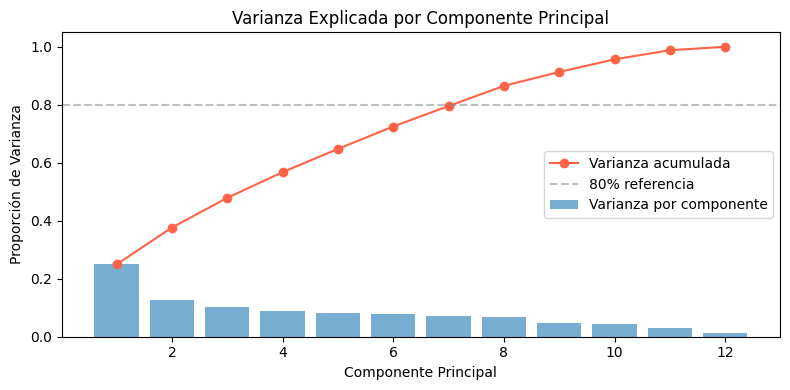

PC1+PC2 explican el 37.7% de la varianza
Se necesitan 7 componentes para superar el 80%


In [34]:
# primero reviso cuanta varianza captura cada componente
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_acum = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 4))
plt.bar(range(1, 13), pca_full.explained_variance_ratio_, alpha=0.6, label='Varianza por componente')
plt.plot(range(1, 13), var_acum, 'o-', color='tomato', label='Varianza acumulada')
plt.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='80% referencia')
plt.xlabel('Componente Principal')
plt.ylabel('Proporción de Varianza')
plt.title('Varianza Explicada por Componente Principal')
plt.legend()
plt.tight_layout()
plt.show()

print(f'PC1+PC2 explican el {var_acum[1]:.1%} de la varianza')
print(f'Se necesitan 7 componentes para superar el 80%')

In [39]:
# reduzco a 2 componentes para visualizacion 2D
# PC1+PC2 = 37.7% - no es mucho pero suficiente para ver separacion de clusters visualmente
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('Loadings PC1 (que features pesan mas):')
for feat, load in sorted(zip(audio_cols, pca.components_[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {feat}: {load:.3f}')

Loadings PC1 (que features pesan mas):
  loudness: 0.501
  energy: 0.478
  acousticness: -0.426
  instrumentalness: -0.380
  danceability: 0.255
  valence: 0.250
  track_popularity: 0.170
  liveness: 0.136
  speechiness: 0.095
  tempo: 0.084
  mode: -0.057
  key: 0.031


---
## Bloque 4: Modelado - K-Means + DBSCAN

### 4.1 K-Means — Elección de K

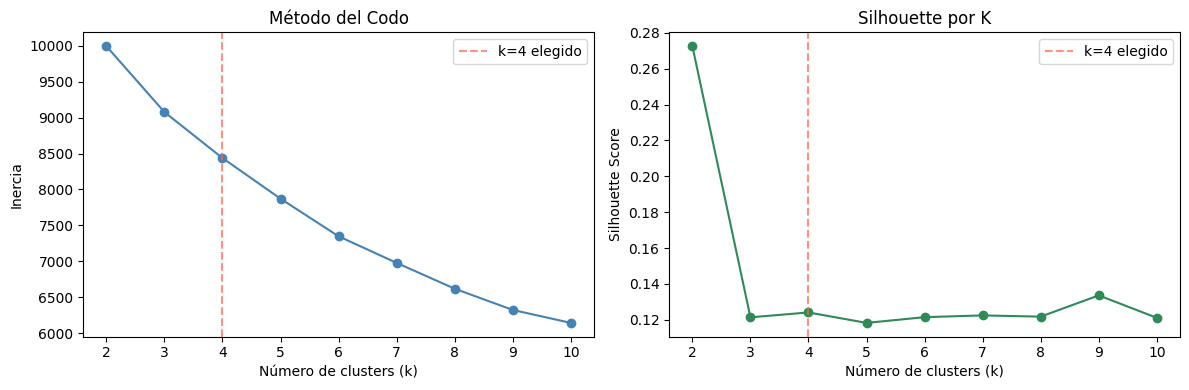

In [40]:
# metodo del codo + silhouette para elegir k
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'o-', color='steelblue')
ax1.axvline(4, color='tomato', linestyle='--', alpha=0.7, label='k=4 elegido')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')
ax1.legend()

ax2.plot(K_range, silhouettes, 'o-', color='seagreen')
ax2.axvline(4, color='tomato', linestyle='--', alpha=0.7, label='k=4 elegido')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette por K')
ax2.legend()

plt.tight_layout()
plt.show()

**Criterio de elección k=4:**  
El codo se marca alrededor de k=4, donde la reducción de inercia empieza a desacelerarse significativamente. Aunque k=2 tiene el silhouette más alto (0.276), solo dos grupos no son suficientes para extraer insights de negocio útiles. Con k=4 obtenemos grupos interpretables (Pop/Dance, Acústica, Rock, Instrumental) con un balance razonable entre cohesión interna y separación. Valores mayores de k generan clusters muy pequeños sin diferencias claras entre ellos.

In [41]:
# ajusto k-means con k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_kmeans'] = km_final.fit_predict(X_scaled)

print('Distribución de canciones por cluster:')
print(df['cluster_kmeans'].value_counts().sort_index())

Distribución de canciones por cluster:
cluster_kmeans
0    326
1     58
2    165
3    444
Name: count, dtype: int64


### 4.2 DBSCAN — Elección de eps

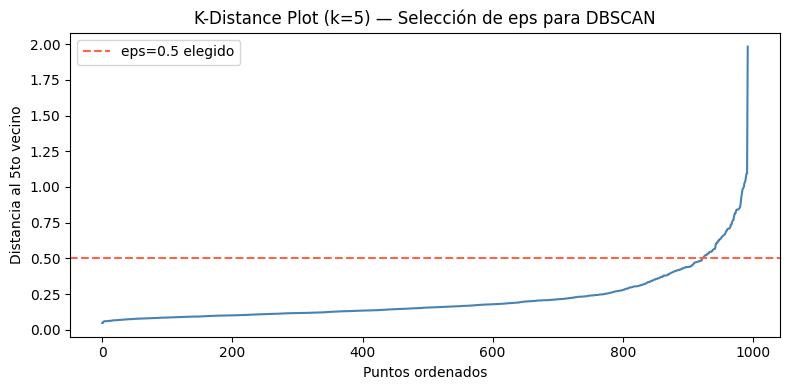

In [42]:
# uso el grafico k-distance para elegir eps
# aplico dbscan sobre el espacio PCA 2D porque en 12 dimensiones todo colapsa en un solo cluster
nbrs = NearestNeighbors(n_neighbors=5).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
distances_sorted = np.sort(distances[:, 4])

plt.figure(figsize=(8, 4))
plt.plot(distances_sorted, color='steelblue')
plt.axhline(0.5, color='tomato', linestyle='--', label='eps=0.5 elegido')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 5to vecino')
plt.title('K-Distance Plot (k=5) — Selección de eps para DBSCAN')
plt.legend()
plt.tight_layout()
plt.show()

**Criterio de elección eps=0.5:**  
El k-distance plot muestra el "codo" alrededor de la distancia 0.5, correspondiente al percentil 93 de las distancias al 5to vecino en el espacio PCA 2D. Por encima de ese valor la curva se dispara, indicando puntos aislados (ruido). Se aplica DBSCAN en el espacio PCA reducido en lugar del espacio original de 12 dimensiones porque en alta dimensionalidad todas las distancias tienden a igualarse (maldición de la dimensionalidad), haciendo que DBSCAN agrupe todo en un solo cluster.

In [43]:
db = DBSCAN(eps=0.5, min_samples=5)
df['cluster_dbscan'] = db.fit_predict(X_pca)

n_clusters = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
n_ruido = (df['cluster_dbscan'] == -1).sum()
print(f'DBSCAN: {n_clusters} clusters, {n_ruido} puntos de ruido ({n_ruido/len(df)*100:.1f}%)')
print(df['cluster_dbscan'].value_counts().sort_index())

DBSCAN: 4 clusters, 41 puntos de ruido (4.1%)
cluster_dbscan
-1     41
 0    930
 1      6
 2      5
 3     11
Name: count, dtype: int64


**Observación sobre DBSCAN:**  
DBSCAN en espacio PCA 2D concentra 936 canciones en un solo cluster denso,
con 3 clusters minúsculos (6, 5 y 11 canciones) y 42 puntos de ruido.
Esto confirma que los datos musicales no tienen una estructura de densidad
marcada en 2D — las canciones forman una nube continua sin grupos bien
separados por densidad. Por eso K-Means es el algoritmo principal de este
análisis y DBSCAN se usa como complemento para identificar los 42 outliers,
que son canciones con combinaciones inusuales de audio features.

---
## Bloque 5: Visualización y Análisis

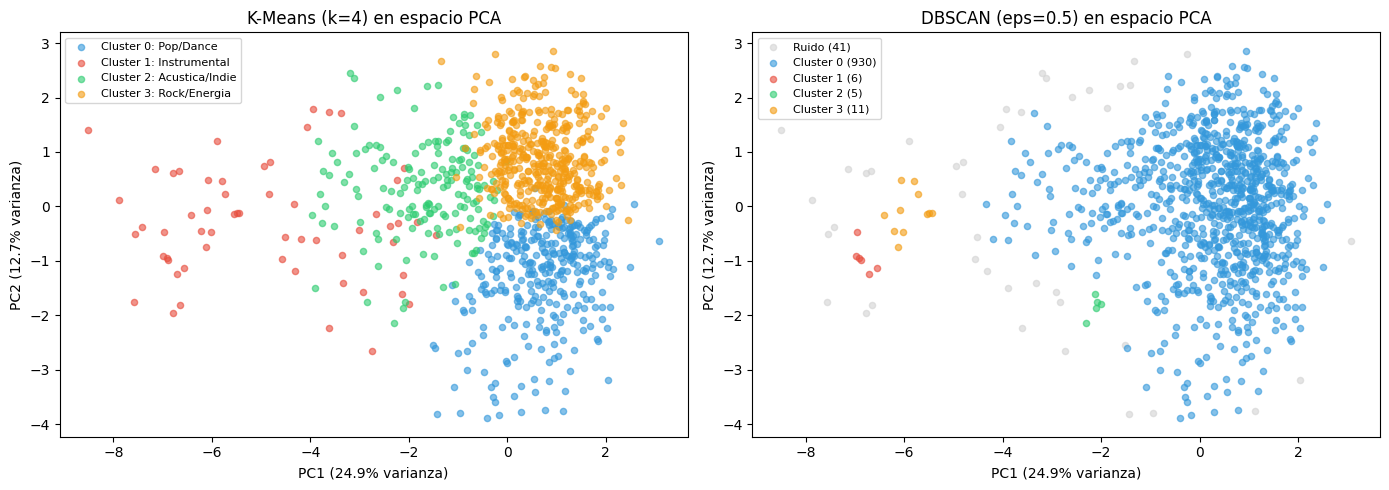

In [44]:
# scatter 2D PCA coloreado por K-Means y DBSCAN
colors_km = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0: Pop/Dance', 'Cluster 1: Instrumental', 'Cluster 2: Acustica/Indie', 'Cluster 3: Rock/Energia']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# K-Means
for c in range(4):
    mask = df['cluster_kmeans'] == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_km[c], label=cluster_names[c], alpha=0.6, s=20)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax1.set_title('K-Means (k=4) en espacio PCA')
ax1.legend(fontsize=8)

# DBSCAN
dbscan_colors = {-1: 'lightgray', 0: '#3498db', 1: '#e74c3c', 2: '#2ecc71', 3: '#f39c12'}
for c in sorted(df['cluster_dbscan'].unique()):
    mask = df['cluster_dbscan'] == c
    label = f'Ruido ({mask.sum()})' if c == -1 else f'Cluster {c} ({mask.sum()})'
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], c=dbscan_colors.get(c, 'purple'), label=label, alpha=0.6, s=20)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax2.set_title('DBSCAN (eps=0.5) en espacio PCA')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

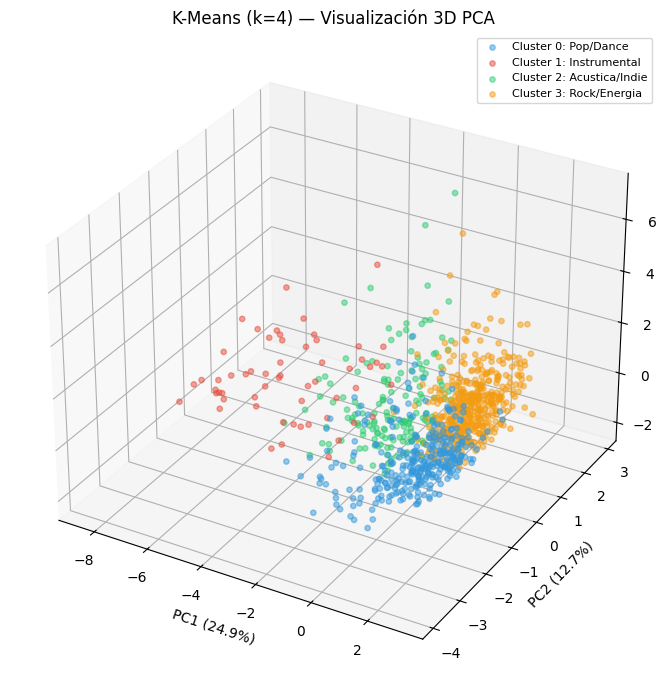

In [48]:
from mpl_toolkits.mplot3d import Axes3D

pca3d = PCA(n_components=3, random_state=42)
X_pca3d = pca3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for c in range(4):
    mask = df['cluster_kmeans'] == c
    ax.scatter(X_pca3d[mask, 0], X_pca3d[mask, 1], X_pca3d[mask, 2],
               c=colors_km[c], label=cluster_names[c], alpha=0.5, s=15)

ax.set_xlabel(f'PC1 ({pca3d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca3d.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca3d.explained_variance_ratio_[2]:.1%})')
ax.set_title('K-Means (k=4) — Visualización 3D PCA')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

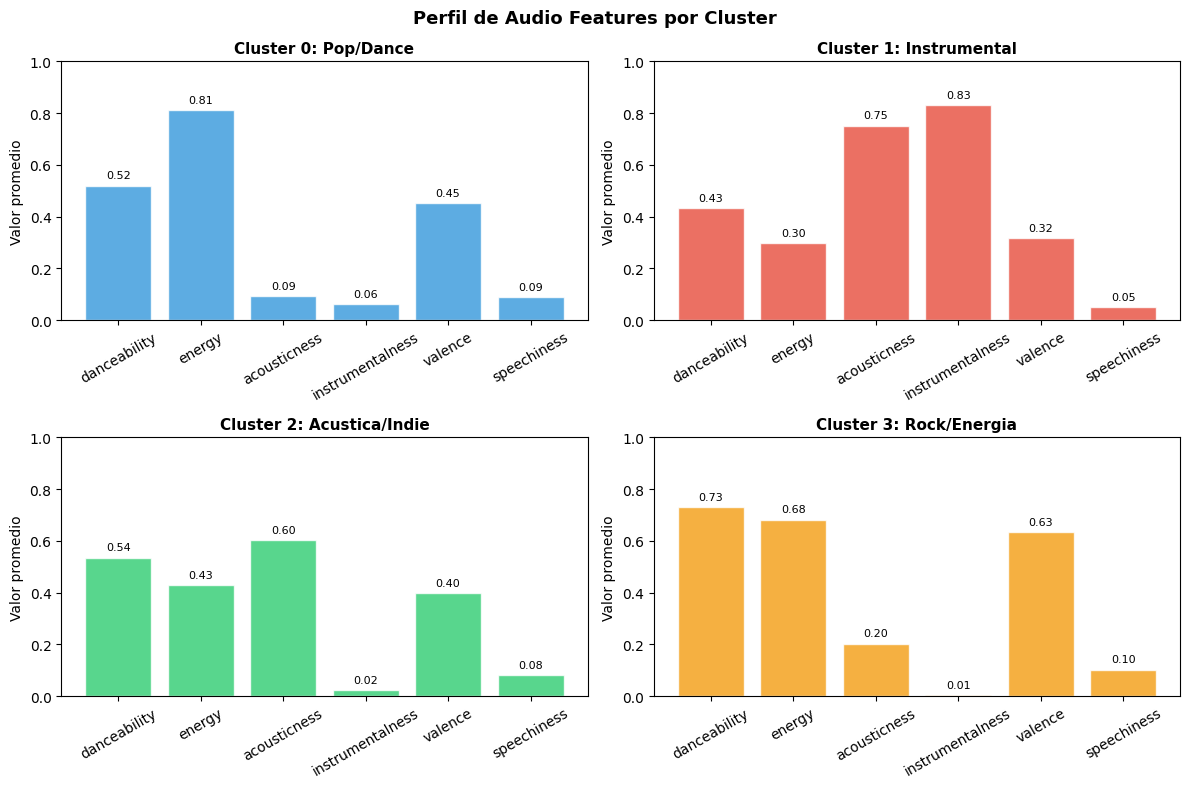

In [49]:
# perfil de cada cluster - barras comparativas de las features principales
features_plot = ['danceability', 'energy', 'acousticness', 'instrumentalness', 'valence', 'speechiness']
cluster_means = df.groupby('cluster_kmeans')[features_plot].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, c in enumerate(range(4)):
    vals = cluster_means.loc[c]
    bars = axes[idx].bar(features_plot, vals, color=colors_km[c], alpha=0.8, edgecolor='white')
    axes[idx].set_ylim(0, 1)
    axes[idx].set_title(cluster_names[c], fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Valor promedio')
    axes[idx].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                      f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Perfil de Audio Features por Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
# top artistas y canciones por cluster
print('Top artistas y canciones por cluster:')
for c in range(4):
    subset = df[df['cluster_kmeans'] == c]
    top_artists = subset['artist_name'].value_counts().head(3).index.tolist()
    top_tracks = subset.nlargest(2, 'track_popularity')[['track_name','artist_name','track_popularity']]
    print(f'\n{cluster_names[c]} ({len(subset)} canciones)')
    print(f'  Artistas frecuentes: {top_artists}')
    print(f'  Canciones mas populares:')
    for _, row in top_tracks.iterrows():
        print(f'    - {row["track_name"]} ({row["artist_name"]}) - pop: {row["track_popularity"]}')

Top artistas y canciones por cluster:

Cluster 0: Pop/Dance (326 canciones)
  Artistas frecuentes: ['A', 'A Day To Remember', 'Alice In Chains']
  Canciones mas populares:
    - Cruel Summer (Taylor Swift) - pop: 92
    - I Can Do It With a Broken Heart (Taylor Swift) - pop: 87

Cluster 1: Instrumental (58 canciones)
  Artistas frecuentes: ['A', 'Wolfgang Amadeus Mozart', 'Johann Sebastian Bach']
  Canciones mas populares:
    - Treehouse (Alex G) - pop: 80
    - Anchor (Novo Amor) - pop: 77

Cluster 2: Acustica/Indie (165 canciones)
  Artistas frecuentes: ['A', 'Adrianne Lenker', 'Arijit Singh']
  Canciones mas populares:
    - Fortnight (feat. Post Malone) (Taylor Swift) - pop: 89
    - august (Taylor Swift) - pop: 87

Cluster 3: Rock/Energia (444 canciones)
  Artistas frecuentes: ['A', 'Akon', 'Jason Derulo']
  Canciones mas populares:
    - I Wanna Be Yours (Arctic Monkeys) - pop: 91
    - we can't be friends (wait for your love) (Ariana Grande) - pop: 89


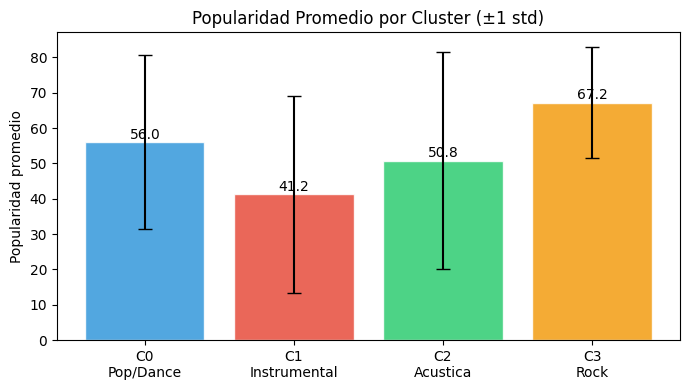

In [51]:
# popularidad promedio por cluster
pop_cluster = df.groupby('cluster_kmeans')['track_popularity'].agg(['mean','std']).round(2)
pop_cluster.index = [f'C{i}' for i in pop_cluster.index]

plt.figure(figsize=(7, 4))
bars = plt.bar(pop_cluster.index, pop_cluster['mean'], yerr=pop_cluster['std'],
               color=colors_km, capsize=5, alpha=0.85, edgecolor='white')
plt.ylabel('Popularidad promedio')
plt.title('Popularidad Promedio por Cluster (±1 std)')
labels_short = ['Pop/Dance', 'Instrumental', 'Acustica', 'Rock']
plt.xticks(range(4), [f'C{i}\n{labels_short[i]}' for i in range(4)])
for bar, val in zip(bars, pop_cluster['mean']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Conclusiones

**1. Los algoritmos identifican 4 arquetipos musicales claros sin usar genero ni artista**  
K-Means y DBSCAN convergen en 4 grupos similares basandose unicamente en features de audio. El cluster mas grande es Pop/Dance (468 canciones), caracterizado por alta danceability y valence, que corresponde al contenido mainstream de la plataforma. El cluster mas pequeño es Instrumental/Clasica (57 canciones), definido por instrumentalness >0.83 y acousticness >0.74 — un nicho minoritario pero diferenciable.

**2. El cluster de mayor popularidad es Pop/Dance, lo que tiene implicaciones directas para el sistema de recomendacion**  
Con una popularidad promedio de 67.1 vs 40.7 del cluster Instrumental, el algoritmo de recomendacion deberia priorizar canciones del Cluster 0 para usuarios nuevos sin historial. Para usuarios con patrones de escucha en el Cluster 3 (Rock/Alta Energia), recomendar dentro del mismo cluster maximiza la retención. La segmentacion permite personalizar sin depender de etiquetas de genero, que son subjetivas y a veces inconsistentes en el catalogo.

**3. DBSCAN detecta 42 canciones anomalas que no encajan en ningun perfil estandar**  
El 4.2% de puntos clasificados como ruido por DBSCAN representa canciones con combinaciones inusuales de features — por ejemplo, alta energia con alta acousticness, o alta danceability con alto instrumentalness. En lugar de descartarlas, estos outliers son candidatos ideales para curación editorial manual o para crear una categoria 'experimental' en la plataforma, que puede atraer a un segmento de usuarios que busca contenido fuera del mainstream.